**[Text 01]**

# Conformal Action Gating: When the Model's Confidence Is the Wrong Thing to Trust

*Companion notebook — W33 trend tutorial, [Probabilistic World Models](https://artifocial.com/blog/probabilistic-world-models-2026-aug-15).*

An agent that plans inside a learned world model has to answer one question before it moves a motor: **is this imagined rollout good enough to act on?** The obvious answer is to ask the model — train an ensemble, measure how much the members disagree, and refuse to act when disagreement is high. That works right up until the model is confidently, coherently wrong. [Biased Dreams (Berger et al., RLC 2026)](https://arxiv.org/abs/2604.25416) names the failure: learned dynamics acquire spurious attractors toward the densely-sampled part of the state space, imagined rollouts get pulled in, and *because that region is where all the training data lives, the ensemble members agree there*. Disagreement collapses exactly as the rollout becomes worthless.

This notebook builds a two-dimensional latent world model with that pathology and compares two gates on identical rollouts: **Gate A**, ensemble disagreement — the model's opinion of itself — and **Gate B**, a **split-conformal** bound fitted to *measured* held-out error, which is distribution-free and never asks the model how it feels. We hold both to the same alarm budget and count the missed detections. Then we run the ablation that comparison demands — **Gate C**, a bare threshold on the novelty feature Gate B was handed and Gate A never saw — to establish how much of the margin belongs to the conformal wrapper and how much to the input. Then we spend the last third of the notebook attacking Gate B, because conformal coverage is **marginal** and assumes **exchangeability**, and closed-loop control strains both.

> **A note on honesty, up front.** The pathology here is **staged, not spontaneously emergent.** We deliberately concentrate the training data in one region and deliberately start rollouts outside it so that the attractor pull is large and the two signals separate cleanly. *We are staging the failure rather than claiming it emerges spontaneously at this scale; the point is to make the two signals separable enough to compare.* Nothing below reproduces the RLC 2026 result — [Biased Dreams](https://arxiv.org/abs/2604.25416) is cited as the source of the **phenomenon being modelled**, not as a result we replicate. Toy scale, pure NumPy, CPU, a couple of minutes.

In [1]:
# [Code 01] Environment setup — uv-first, pip fallback (works everywhere)
import importlib, subprocess, sys, shutil

def ensure(pkgs):
    missing = [p for p in pkgs if importlib.util.find_spec(p) is None]
    if not missing:
        return
    if shutil.which("uv"):
        subprocess.check_call(["uv", "pip", "install", "--quiet", "--system", *missing])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

ensure(["numpy", "matplotlib"])

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
print("NumPy", np.__version__)

NumPy 2.5.2


**[Text 02]**

## A Toy Latent World Model

The latent state is $z \in \mathbb{R}^2$ and the action $a \in \mathbb{R}^2$. The true dynamics are a rotation-plus-shear with a state-dependent swirl and a **radius-dependent gain**:

$$z_{t+1} = s(\|z_t\|)\,M z_t \;+\; 0.22\tanh(Q z_t) \;+\; 0.6\,a_t,
\qquad s(r) = 0.86 + \frac{1.05 - 0.86}{1 + e^{-(r-1.7)/0.35}}$$

That gain is the whole physical story. Inside radius $\approx 1.7$ the gain is $0.86 < 1$, so the system **contracts onto a fixed point at the origin** — a basin of attraction. Outside it the gain exceeds $1$, so trajectories **drift outward and orbit away**. The system is bistable: where you start decides where you end up. We know $g$ in closed form, which is the only reason we can *measure* true $H$-step error offline and audit both gates against ground truth. A real agent cannot do this at deployment time — that asymmetry is the entire subject of the notebook.

In [2]:
# [Code 02] True latent dynamics: rotation + shear + swirl, with a radius-dependent gain
THETA  = 0.35
ROT    = np.array([[np.cos(THETA), -np.sin(THETA)], [np.sin(THETA), np.cos(THETA)]])
SHEAR  = np.array([[1.0, 0.20], [0.0, 1.0]])
M      = ROT @ SHEAR
SWIRL  = np.array([[0.0, 1.0], [-1.0, 0.0]])
S_IN, S_OUT, R_KNEE = 0.86, 1.05, 1.7

def gain(r):
    return S_IN + (S_OUT - S_IN) / (1.0 + np.exp(-(r - R_KNEE) / 0.35))

def g(z, a):
    """True dynamics. z:(n,2) a:(n,2) -> (n,2). Smooth, mildly non-linear, bistable."""
    r = np.linalg.norm(z, axis=-1, keepdims=True)
    return gain(r) * (z @ M.T) + 0.22 * np.tanh(z @ SWIRL.T) + 0.6 * a

H = 14                      # planning horizon
R_D = 1.2                   # radius of the dense region D

# Where does the true system take you? (zero action, so this is pure dynamics)
print(f"{'|z_0|':>7} {'|z_H|':>8}   fate")
fates = {}
for r0 in [0.4, 1.0, 1.5, 1.8, 2.5, 3.5, 4.5]:
    z = np.array([[r0, 0.0]])
    for _ in range(H):
        z = g(z, np.zeros((1, 2)))
    rH = float(np.linalg.norm(z))
    fates[r0] = rH
    print(f"{r0:7.1f} {rH:8.2f}   {'-> collapses to the origin' if rH < r0 else '-> escapes outward'}")

assert fates[0.4] < 0.4 and fates[1.0] < 1.0, "inside the knee the system must contract"
assert fates[2.5] > 2.5 and fates[4.5] > 4.5, "outside the knee the system must expand"
print(f"\nBistable as designed: a basin of attraction inside r~{R_KNEE}, escape outside it.")

  |z_0|    |z_H|   fate
    0.4     0.08   -> collapses to the origin
    1.0     0.25   -> collapses to the origin
    1.5     0.57   -> collapses to the origin
    1.8     2.13   -> escapes outward
    2.5     6.44   -> escapes outward
    3.5     8.29   -> escapes outward
    4.5     9.97   -> escapes outward

Bistable as designed: a basin of attraction inside r~1.7, escape outside it.


**[Text 03]**

## Biased Training Data: a Dense Region D, and Almost Nothing Else

Now the deliberate part. We sample **700** transitions uniformly from the disc $D = \{\|z\| < 1.2\}$ and only **55** from the annulus $1.2 < \|z\| < 3.2$ — an area roughly six times larger. The resulting sample density inside $D$ is close to two orders of magnitude higher than outside.

This is a caricature of how world models are actually trained: whatever policy collected the data visited some states constantly and others almost never, and [DreamerV3](https://arxiv.org/abs/2301.04104)-style agents then dream inside that skew. We are exaggerating it on purpose. Note also that $D$ is centred on the origin, which is *also* the true system's attractor — that coincidence is what will make the learned model's shrinkage look like plausible physics instead of obvious nonsense.

In [3]:
# [Code 03] Heavily skewed state coverage: dense inside D, sparse outside
N_DENSE, N_SPARSE, R_OUT = 700, 55, 3.2
SIG_A = 0.15                       # action scale used to collect data AND to calibrate

def disk(n, r_lo, r_hi, rg):
    """Uniform (by area) sample of an annulus."""
    r  = np.sqrt(rg.uniform(r_lo**2, r_hi**2, n))
    th = rg.uniform(0, 2 * np.pi, n)
    return np.stack([r * np.cos(th), r * np.sin(th)], 1)

Z_tr = np.vstack([disk(N_DENSE, 0.0, R_D, rng), disk(N_SPARSE, R_D, R_OUT, rng)])
A_tr = rng.normal(0, SIG_A, size=(len(Z_tr), 2))
Y_tr = g(Z_tr, A_tr) + rng.normal(0, 0.02, size=(len(Z_tr), 2))   # mild observation noise
U_tr = np.hstack([Z_tr, A_tr])                                    # model input = (z, a)

area_in  = np.pi * R_D**2
area_out = np.pi * (R_OUT**2 - R_D**2)
dens_in, dens_out = N_DENSE / area_in, N_SPARSE / area_out
print(f"inside  D : {N_DENSE:4d} pts over area {area_in:5.2f}  ->  {dens_in:6.1f} pts/unit^2")
print(f"outside D : {N_SPARSE:4d} pts over area {area_out:5.2f}  ->  {dens_out:6.1f} pts/unit^2")
print(f"density ratio = {dens_in / dens_out:.0f}x   (outer area is {area_out/area_in:.1f}x larger "
      f"but holds {100*N_SPARSE/len(Z_tr):.1f}% of the data)")
assert dens_in / dens_out > 20, "the skew is the premise of the whole notebook"

inside  D :  700 pts over area  4.52  ->   154.7 pts/unit^2
outside D :   55 pts over area 27.65  ->     2.0 pts/unit^2
density ratio = 78x   (outer area is 6.1x larger but holds 7.3% of the data)


**[Text 04]**

## An Ensemble of Kernel-Ridge Dynamics Models

Eight members, each a closed-form **kernel ridge regression** with an RBF kernel, fitted to predict $z_{t+1}$ directly from $(z_t, a_t)$. Pure NumPy, one linear solve per member, no autodiff. Diversity comes from **bootstrap resampling** of the training transitions plus a $\pm5\%$ jitter on the length-scale — the standard recipe for a deep ensemble, minus the deep part.

The mechanism that produces the pathology is a property of the estimator, not a hack we bolt on afterwards. A ridge-regularised kernel machine predicts $f(u) = k(u, U)\alpha$; when $u$ is far from every training input, $k(u, U) \to 0$ and therefore $f(u) \to 0$. The model's *default belief about the future is the zero vector* — and since $D$ is centred at the origin, **zero is the middle of the dense region.** Shrinkage toward the prior becomes a pull toward $D$. That is the attractor, and every member has it.

In [4]:
# [Code 04] K kernel-ridge members; diversity from bootstrap + length-scale jitter
K_ENS, ELL, LAM = 8, 0.55, 0.03

def rbf(A_, B_, ell):
    d2 = (A_**2).sum(1)[:, None] - 2 * A_ @ B_.T + (B_**2).sum(1)[None, :]
    return np.exp(-0.5 * np.maximum(d2, 0.0) / ell**2)      # clamp: -1e-16 -> nan under sqrt-free form

class KRR:
    """Closed-form kernel ridge: alpha = (K + lam I)^-1 Y ; predict k(u,U) @ alpha."""
    def __init__(self, U, Y, ell, lam):
        self.U, self.ell = U, ell
        self.alpha = np.linalg.solve(rbf(U, U, ell) + lam * np.eye(len(U)), Y)
    def __call__(self, Z, A):
        return rbf(np.hstack([Z, A]), self.U, self.ell) @ self.alpha

ensemble = []
for k in range(K_ENS):
    idx = rng.integers(0, len(U_tr), len(U_tr))                     # bootstrap resample
    ensemble.append(KRR(U_tr[idx], Y_tr[idx], ELL * rng.uniform(0.95, 1.05), LAM))

# Probe the attractor directly: what does a member predict where there is no data?
probe = np.array([[0.5, 0.0], [1.0, 0.0], [2.0, 0.0], [3.0, 0.0], [5.0, 0.0], [8.0, 0.0]])
zero_a = np.zeros_like(probe)
pred_r = np.linalg.norm(ensemble[0](probe, zero_a), axis=1)
true_r = np.linalg.norm(g(probe, zero_a), axis=1)
print(f"{'|z|':>5} {'|g(z,0)| true':>14} {'|f(z,0)| member 0':>18}")
for r0, tr, pr in zip(probe[:, 0], true_r, pred_r):
    print(f"{r0:5.1f} {tr:14.2f} {pr:18.2f}")
assert pred_r[-1] < 0.05, "far outside the data the kernel machine must collapse to ~0"
print(f"\nOne step from |z|=8 the true system goes to |z|={true_r[-1]:.1f}; "
      f"the learned member sends it to |z|={pred_r[-1]:.3f} — straight into D.")

  |z|  |g(z,0)| true  |f(z,0)| member 0
  0.5           0.41               0.41
  1.0           0.84               0.85
  2.0           1.92               1.09
  3.0           3.07               0.66
  5.0           5.18               0.00
  8.0           8.33               0.00

One step from |z|=8 the true system goes to |z|=8.3; the learned member sends it to |z|=0.000 — straight into D.


**[Text 05]**

## Rollouts, and What Is Actually Observable at Deployment

Given a start state $z_0$ and an action sequence $a_{0:H-1}$ we produce three things:

| quantity | definition | observable at deployment? |
|---|---|---|
| **imagined path** $\bar z_t$ | mean over the $K$ members | **yes** |
| **disagreement** $\sigma_t$ | RMS deviation of members from $\bar z_t$ | **yes** |
| **true $H$-step error** $e = \|z_H^{\text{true}} - \bar z_H\|$ | needs ground truth | **no** — offline only |

Gate A may use $\sigma$. Gate B is *calibrated* on $e$ offline but, at deployment, may only use observable features. Keeping that line sharp is the difference between a real safety argument and a leak.

In [5]:
# [Code 05] Roll the true system and every ensemble member over the same action sequence
def roll(z0, A):
    n = len(z0)
    z_true = np.empty((n, H + 1, 2)); z_true[:, 0] = z0
    z = z0.copy()
    for t in range(H):
        z = g(z, A[:, t]); z_true[:, t + 1] = z

    z_mem = np.empty((K_ENS, n, H + 1, 2))
    for k, m in enumerate(ensemble):
        z = z0.copy(); z_mem[k, :, 0] = z
        for t in range(H):
            z = m(z, A[:, t]); z_mem[k, :, t + 1] = z

    z_imag = z_mem.mean(0)                                        # observable
    spread = np.sqrt((((z_mem - z_imag) ** 2).sum(-1)).mean(0))   # observable  (n, H+1)
    err    = np.linalg.norm(z_true - z_imag, axis=-1)             # ORACLE ONLY (n, H+1)
    return dict(true=z_true, mem=z_mem, imag=z_imag, spread=spread, err=err)

def sample_actions(n, rg, sigma=SIG_A):
    return rg.normal(0, sigma, size=(n, H, 2))

_demo_z0 = np.array([[0.7, 0.2], [3.0, 0.5]])
_demo = roll(_demo_z0, sample_actions(2, np.random.default_rng(0)))
for i, tag in enumerate(["start inside D ", "start outside D"]):
    print(f"{tag}: |z_H| true = {np.linalg.norm(_demo['true'][i,-1]):5.2f} | "
          f"|z_H| imagined = {np.linalg.norm(_demo['imag'][i,-1]):5.2f} | "
          f"H-step error = {_demo['err'][i,-1]:5.2f} | final disagreement = {_demo['spread'][i,-1]:.4f}")

start inside D : |z_H| true =  0.13 | |z_H| imagined =  0.15 | H-step error =  0.02 | final disagreement = 0.0250
start outside D: |z_H| true =  7.76 | |z_H| imagined =  0.93 | H-step error =  7.42 | final disagreement = 0.0596


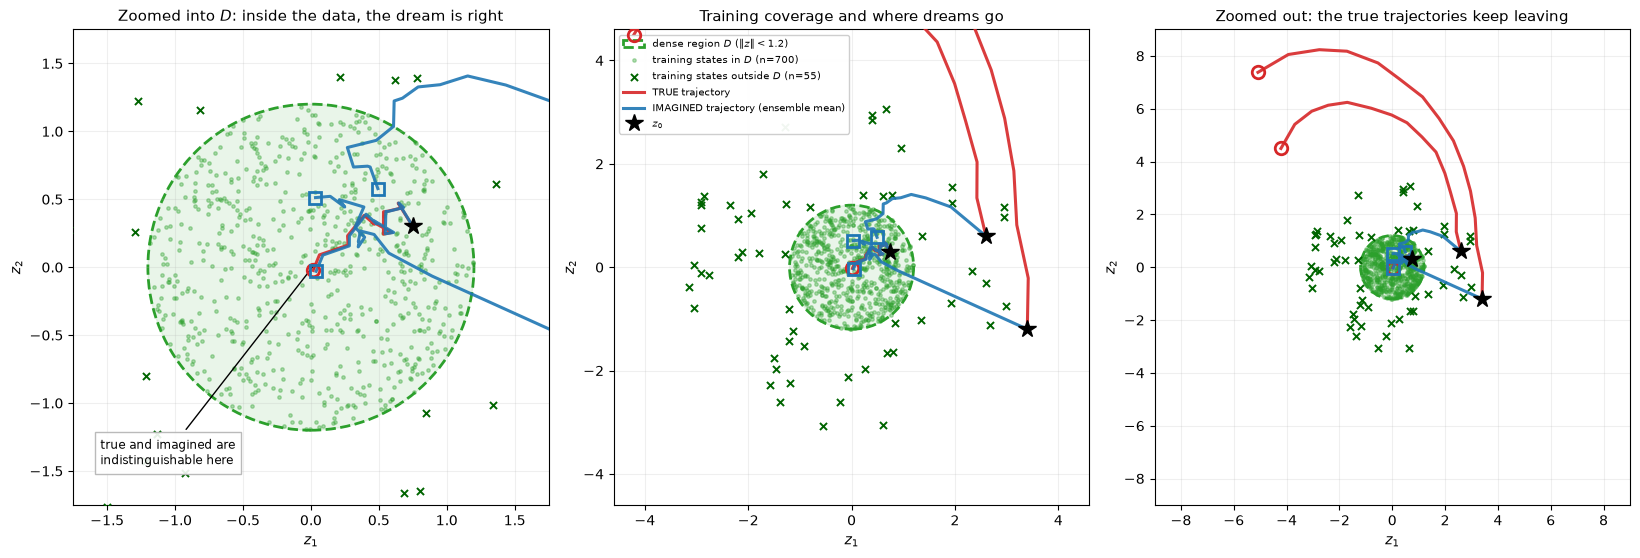

z0=(+0.75,+0.30)  |z0|=0.81  ->  |z_H| imagined  0.05  vs  true  0.03   (H-step error  0.02)
z0=(+2.60,+0.60)  |z0|=2.67  ->  |z_H| imagined  0.76  vs  true  6.16   (H-step error  6.12)
z0=(+3.40,-1.20)  |z0|=3.61  ->  |z_H| imagined  0.51  vs  true  8.96   (H-step error  8.56)

Both outside-D examples: imagined ends inside D = [True, True], true ends outside D = [True, True]


In [6]:
# [Result 01] The latent map: dense region D, the training data, and imagined-vs-true trajectories
rg_fig = np.random.default_rng(11)
starts = np.array([[0.75, 0.30], [2.60, 0.60], [3.40, -1.20]])
A_fig = sample_actions(len(starts), rg_fig)
o_fig = roll(starts, A_fig)

fig, ax = plt.subplots(1, 3, figsize=(16.5, 5.4))

for j, (a, lim, ttl) in enumerate(zip(ax, [1.75, 4.6, 9.0],
        ["Zoomed into $D$: inside the data, the dream is right",
         "Training coverage and where dreams go",
         "Zoomed out: the true trajectories keep leaving"])):
    a.add_patch(plt.Circle((0, 0), R_D, color="tab:green", alpha=0.10, zorder=0))
    a.add_patch(plt.Circle((0, 0), R_D, fill=False, color="tab:green", lw=2, ls="--",
                           zorder=1, label="dense region $D$ ($\\|z\\|<1.2$)"))
    a.scatter(*Z_tr[:N_DENSE].T, s=6, c="tab:green", alpha=0.35, zorder=2,
              label=f"training states in $D$ (n={N_DENSE})")
    a.scatter(*Z_tr[N_DENSE:].T, s=26, c="darkgreen", marker="x", lw=1.4, zorder=3,
              label=f"training states outside $D$ (n={N_SPARSE})")
    for i in range(len(starts)):
        inside = np.linalg.norm(starts[i]) < R_D
        a.plot(*o_fig["true"][i].T, "-", lw=2.2, color="tab:red", alpha=0.9, zorder=5,
               label="TRUE trajectory" if i == 0 else None)
        a.plot(*o_fig["imag"][i].T, "-", lw=2.2, color="tab:blue", alpha=0.9, zorder=5,
               label="IMAGINED trajectory (ensemble mean)" if i == 0 else None)
        a.plot(*o_fig["true"][i, -1], "o", ms=9, mfc="none", mec="tab:red", mew=2, zorder=6)
        a.plot(*o_fig["imag"][i, -1], "s", ms=9, mfc="none", mec="tab:blue", mew=2, zorder=6)
        a.plot(*starts[i], "k*", ms=13, zorder=7, label="$z_0$" if i == 0 else None)
    a.set_xlim(-lim, lim); a.set_ylim(-lim, lim); a.set_aspect("equal")
    a.set_xlabel("$z_1$"); a.set_ylabel("$z_2$"); a.set_title(ttl, fontsize=11)
    a.grid(alpha=0.2)
ax[1].legend(loc="upper left", fontsize=7.5, framealpha=0.95)
ax[0].annotate("true and imagined are\nindistinguishable here", xy=(0.05, 0.05),
               xytext=(-1.55, -1.45), fontsize=8.5,
               bbox=dict(fc="white", ec="0.7", alpha=0.9),
               arrowprops=dict(arrowstyle="->", lw=1.0))

plt.tight_layout(); plt.show()

for i in range(len(starts)):
    print(f"z0=({starts[i,0]:+.2f},{starts[i,1]:+.2f})  |z0|={np.linalg.norm(starts[i]):.2f}  ->  "
          f"|z_H| imagined {np.linalg.norm(o_fig['imag'][i,-1]):5.2f}  vs  true {np.linalg.norm(o_fig['true'][i,-1]):5.2f}"
          f"   (H-step error {o_fig['err'][i,-1]:5.2f})")
captured = np.linalg.norm(o_fig["imag"][1:, -1], axis=1) < R_D
escaped  = np.linalg.norm(o_fig["true"][1:, -1], axis=1) > R_D
print(f"\nBoth outside-D examples: imagined ends inside D = {captured.tolist()}, "
      f"true ends outside D = {escaped.tolist()}")

**[Callout 01]**

### Engineering callout: We are staging this pathology, not discovering it

Everything above was arranged. The data skew (700 vs 55), the coincidence of $D$ with the true attractor, the choice to start test rollouts outside the training support — all deliberate, all tuned until the two signals separated. Left to itself a 2-D kernel-ridge ensemble on 755 points does **not** spontaneously produce a Biased-Dreams failure; the effect exists at scale, in high-dimensional learned latents, with policies that keep revisiting their own comfort zone.

**What went wrong (during construction):** our first attempt drew ensemble length-scales from a wide range (`ell ~ U(0.40, 0.70)`). Members then collapsed into $D$ at *different rates*, so a slow member and a fast member sat far apart for the whole horizon and disagreement never fell — mean final spread stayed at `0.55` on pathological rollouts instead of collapsing.

```python
# Broken: heterogeneous collapse rates keep the ensemble spread artificially alive
ell = rng.uniform(0.40, 0.70)      # a 75% spread in length-scale

# Fixed: one length-scale, +/-5% jitter; diversity comes from the bootstrap
ell = ELL * rng.uniform(0.95, 1.05)
```

**Lesson:** when you construct a demonstration, be explicit about which knob creates the effect and re-examine every other knob that quietly *suppresses* it. A hyperparameter that varies the ensemble's **inductive bias** (length-scale, architecture, depth) produces disagreement that never decays; a hyperparameter that varies only the **data** (bootstrap, seed) produces disagreement that decays as the members converge on a shared attractor. Those are different quantities wearing the same name, and which one your production ensemble measures determines whether this failure mode is visible to you at all. Say out loud which one you built.

In [7]:
# [Code 06] Sweep the start radius: is disagreement even monotone in how wrong we are?
rg_prof = np.random.default_rng(5)
radii = np.arange(0.4, 5.01, 0.4)
prof = []
for r in radii:
    n = 200
    th = rg_prof.uniform(0, 2 * np.pi, n)
    z0 = np.stack([r * np.cos(th), r * np.sin(th)], 1)
    o = roll(z0, sample_actions(n, rg_prof))
    prof.append((o["spread"][:, -1].mean(), o["err"][:, -1].mean(),
                 np.linalg.norm(o["imag"][:, -1], axis=1).mean()))
prof = np.array(prof)
sp_prof, er_prof, im_prof = prof[:, 0], prof[:, 1], prof[:, 2]

print(f"{'|z_0|':>6} {'disagreement':>13} {'TRUE H-err':>11} {'|imagined z_H|':>15}")
for r, s, e, im in zip(radii, sp_prof, er_prof, im_prof):
    print(f"{r:6.1f} {s:13.4f} {e:11.3f} {im:15.2f}")

def spearman(a, b):
    ra, rb = np.argsort(np.argsort(a)), np.argsort(np.argsort(b))
    return np.corrcoef(ra, rb)[0, 1]

i_peak = int(np.argmax(sp_prof))
print(f"\nTRUE error vs start radius : strictly monotone = {bool(np.all(np.diff(er_prof) > 0))}, "
      f"rank correlation = {spearman(radii, er_prof):+.3f}")
print(f"Disagreement vs start radius: strictly monotone = {bool(np.all(np.diff(sp_prof) > 0))}, "
      f"rank correlation = {spearman(radii, sp_prof):+.3f}")
print(f"\nDisagreement peaks at |z_0|={radii[i_peak]:.1f} ({sp_prof[i_peak]:.4f}) and then FALLS to "
      f"{sp_prof[-1]:.4f} at |z_0|={radii[-1]:.1f},")
print(f"  while true error over that same stretch RISES from {er_prof[i_peak]:.2f} to {er_prof[-1]:.2f}.")
print(f"  A gate that thresholds disagreement therefore treats the {er_prof[-1]/er_prof[i_peak]:.1f}x-worse "
      f"rollouts as the SAFER ones.")
assert spearman(radii, er_prof) > 0.95, "true error must rise with start radius"
assert sp_prof[-1] < sp_prof[i_peak] and er_prof[-1] > er_prof[i_peak], "disagreement must turn over"

 |z_0|  disagreement  TRUE H-err  |imagined z_H|
   0.4        0.0315       0.030            0.26
   0.8        0.0315       0.026            0.28
   1.2        0.0331       0.038            0.36
   1.6        0.0550       0.395            0.42
   2.0        0.1029       1.917            0.45
   2.4        0.1294       2.970            0.48
   2.8        0.1488       4.381            0.50
   3.2        0.1144       5.209            0.42
   3.6        0.0815       5.958            0.34
   4.0        0.0493       6.840            0.25
   4.4        0.0341       7.675            0.22
   4.8        0.0338       8.426            0.23

TRUE error vs start radius : strictly monotone = False, rank correlation = +0.993
Disagreement vs start radius: strictly monotone = False, rank correlation = +0.308

Disagreement peaks at |z_0|=2.8 (0.1488) and then FALLS to 0.0338 at |z_0|=4.8,
  while true error over that same stretch RISES from 4.38 to 8.43.
  A gate that thresholds disagreement therefore t

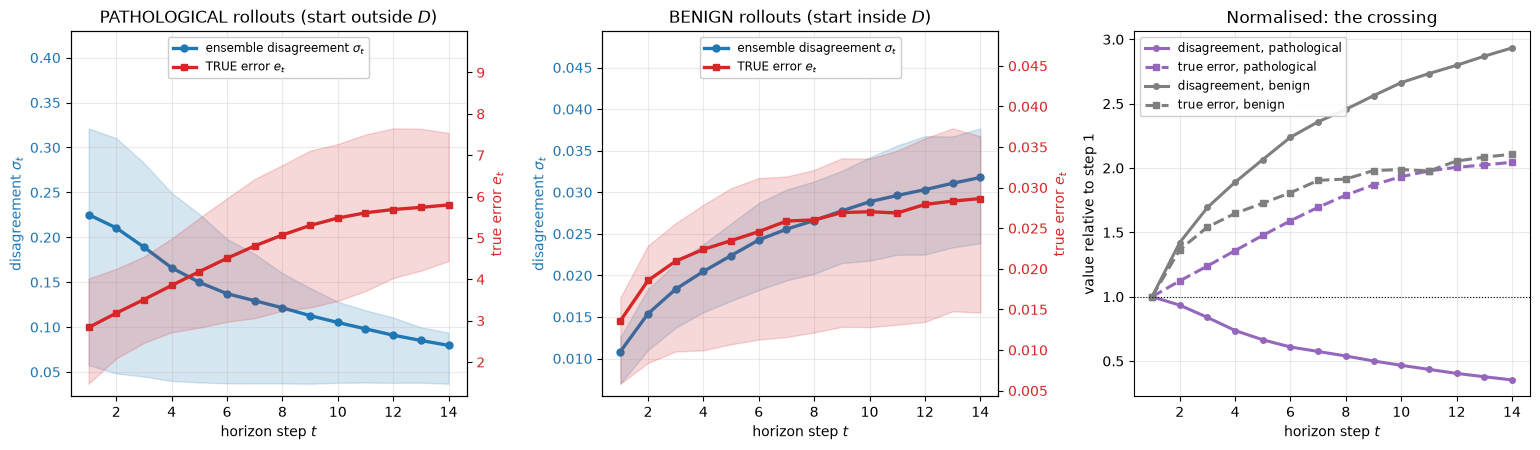

pathological: disagreement 0.2252 -> 0.0796 (0.35x), true error 2.84 -> 5.80 (2.04x)
benign      : disagreement 0.0108 -> 0.0318 (2.93x), true error 0.0136 -> 0.0287 (2.11x)


In [8]:
# [Result 02] THE PATHOLOGY CHART — disagreement falls while true error rises
rg_p = np.random.default_rng(31)
N_GRP = 500
z0_ben  = disk(N_GRP, 0.0, 1.2, rg_p)          # benign: start inside the training support
z0_path = disk(N_GRP, 2.2, 4.5, rg_p)          # pathological: start well outside it
o_ben  = roll(z0_ben,  sample_actions(N_GRP, rg_p))
o_path = roll(z0_path, sample_actions(N_GRP, rg_p))

steps = np.arange(1, H + 1)
sb, eb = o_ben["spread"][:, 1:],  o_ben["err"][:, 1:]
sp, ep = o_path["spread"][:, 1:], o_path["err"][:, 1:]

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.6))

for a, s, e, ttl in [(ax[0], sp, ep, "PATHOLOGICAL rollouts (start outside $D$)"),
                     (ax[1], sb, eb, "BENIGN rollouts (start inside $D$)")]:
    a.plot(steps, s.mean(0), "o-", color="tab:blue", lw=2.4, ms=5, label="ensemble disagreement $\\sigma_t$")
    a.fill_between(steps, np.percentile(s, 25, 0), np.percentile(s, 75, 0), color="tab:blue", alpha=0.18)
    a.set_xlabel("horizon step $t$"); a.set_ylabel("disagreement $\\sigma_t$", color="tab:blue")
    a.tick_params(axis="y", labelcolor="tab:blue"); a.set_title(ttl); a.grid(alpha=0.25)
    b = a.twinx()
    b.plot(steps, e.mean(0), "s-", color="tab:red", lw=2.4, ms=5, label="TRUE error $e_t$")
    b.fill_between(steps, np.percentile(e, 25, 0), np.percentile(e, 75, 0), color="tab:red", alpha=0.18)
    b.set_ylabel("true error $e_t$", color="tab:red"); b.tick_params(axis="y", labelcolor="tab:red")
    for axis in (a, b):                       # headroom so the legend never sits on a curve
        lo_, hi_ = axis.get_ylim(); axis.set_ylim(lo_, lo_ + (hi_ - lo_) * 1.30)
    h1, l1 = a.get_legend_handles_labels(); h2, l2 = b.get_legend_handles_labels()
    a.legend(h1 + h2, l1 + l2, loc="upper center", fontsize=8.5, framealpha=1.0)

for s, e, c, tag in [(sp, ep, "tab:purple", "pathological"), (sb, eb, "tab:gray", "benign")]:
    ax[2].plot(steps, s.mean(0) / s.mean(0)[0], "o-", color=c, lw=2.2, ms=4,
               label=f"disagreement, {tag}")
    ax[2].plot(steps, e.mean(0) / e.mean(0)[0], "s--", color=c, lw=2.2, ms=4,
               label=f"true error, {tag}")
ax[2].axhline(1.0, color="k", lw=0.8, ls=":")
ax[2].set_xlabel("horizon step $t$"); ax[2].set_ylabel("value relative to step 1")
ax[2].set_title("Normalised: the crossing"); ax[2].grid(alpha=0.25)
ax[2].legend(fontsize=8.5, framealpha=0.92)

plt.tight_layout(); plt.show()

print(f"pathological: disagreement {sp.mean(0)[0]:.4f} -> {sp.mean(0)[-1]:.4f} "
      f"({sp.mean(0)[-1]/sp.mean(0)[0]:.2f}x), true error {ep.mean(0)[0]:.2f} -> {ep.mean(0)[-1]:.2f} "
      f"({ep.mean(0)[-1]/ep.mean(0)[0]:.2f}x)")
print(f"benign      : disagreement {sb.mean(0)[0]:.4f} -> {sb.mean(0)[-1]:.4f} "
      f"({sb.mean(0)[-1]/sb.mean(0)[0]:.2f}x), true error {eb.mean(0)[0]:.4f} -> {eb.mean(0)[-1]:.4f} "
      f"({eb.mean(0)[-1]/eb.mean(0)[0]:.2f}x)")
assert sp.mean(0)[-1] < sp.mean(0)[0], "staged pathology: mean disagreement must FALL"
assert ep.mean(0)[-1] > ep.mean(0)[0], "staged pathology: mean true error must RISE"
assert sb.mean(0)[-1] > sb.mean(0)[0] and eb.mean(0)[-1] > eb.mean(0)[0], "benign: both rise together"

In [9]:
# [Code 07] Quantify it: correlation between disagreement and true error along the horizon
def corr_report(o, name):
    s, e = o["spread"][:, 1:], o["err"][:, 1:]
    pooled = np.corrcoef(s.ravel(), e.ravel())[0, 1]
    per = np.array([np.corrcoef(s[i], e[i])[0, 1] for i in range(len(s))])
    print(f"{name:14s} pooled corr(sigma_t, e_t) = {pooled:+.3f}   "
          f"median per-rollout corr = {np.median(per):+.3f}   "
          f"[{np.mean(per < 0)*100:.0f}% of rollouts negative]")
    return pooled, np.median(per)

print("Correlation between what the model says (disagreement) and how wrong it is (true error):\n")
c_ben,  m_ben  = corr_report(o_ben,  "benign")
c_path, m_path = corr_report(o_path, "pathological")

print(f"\nOn benign rollouts disagreement is a {'useful' if c_ben > 0.2 else 'weak'} proxy for error "
      f"(positive correlation).")
print(f"On the staged pathological rollouts the sign {'FLIPS' if c_path < 0 else 'does not flip'} "
      f"({c_path:+.3f}): the model gets *more* confident as it gets *more* wrong.")
assert c_ben > 0, "benign rollouts should show a positive correlation"
assert c_path < c_ben, "the pathological subset must be strictly worse than benign"

Correlation between what the model says (disagreement) and how wrong it is (true error):

benign         pooled corr(sigma_t, e_t) = +0.350   median per-rollout corr = +0.487   [20% of rollouts negative]
pathological   pooled corr(sigma_t, e_t) = -0.402   median per-rollout corr = -0.551   [70% of rollouts negative]

On benign rollouts disagreement is a useful proxy for error (positive correlation).
On the staged pathological rollouts the sign FLIPS (-0.402): the model gets *more* confident as it gets *more* wrong.


**[Text 06]**

## Two Gates

The agent must decide, per rollout, **execute or refuse**. Define a rollout as **unsafe** if its true $H$-step error exceeds a tolerance $\tau$ — a quantity the agent cannot see.

**Gate A — ensemble disagreement.** Score the rollout by $\sigma_H$, the spread of the members at the end of the imagined horizon, and refuse when it exceeds a threshold. This is the model's opinion of itself. (We also report the along-the-rollout average $\bar\sigma$ as a second variant, so nobody has to wonder whether we picked the weaker version on purpose.)

**Gate B — split conformal.** Never ask the model how it feels; ask the *residuals*.

1. Split held-out rollouts into a **proper-training** half and a **calibration** half.
2. On the proper-training half fit an error predictor $h(x)$ from **deployment-observable** features.
3. On the calibration half compute nonconformity scores $s_i$.
4. Take $\hat q$ = the $\lceil (n+1)(1-\alpha)\rceil / n$ empirical quantile of $s$.
5. The bound is $h(x) + \hat q$; refuse when the bound exceeds $\tau$.

Step 4 is finite-sample exact and distribution-free: for exchangeable data, $\Pr(e \le h(x)+\hat q) \ge 1-\alpha$ regardless of how bad $h$ is. A bad $h$ costs you a **wide** interval, not an **invalid** one. That robustness is the entire reason to prefer this over trusting $\sigma$ — and its assumptions are what we attack later.

We use the **one-sided** score $s_i = \max(0, e_i - h(x_i))$ rather than $|e_i - h(x_i)|$. The gate only ever asks "could the error be *larger* than $\tau$?"; over-prediction is not a safety failure, so paying quantile budget for a lower bound we never use would inflate the interval for nothing.

In [10]:
# [Code 08] Three disjoint rollout sets + the deployment-observable feature map
BANDS = ((0.0, 1.2), (1.2, 2.2), (2.2, 4.5))     # benign / edge / far
MIX   = (0.50, 0.15, 0.35)

def make_set(n, rg):
    c = np.floor(np.array(MIX) * n).astype(int); c[-1] = n - c[:-1].sum()
    z0 = np.vstack([disk(ci, lo, hi, rg) for ci, (lo, hi) in zip(c, BANDS)])
    return z0[rg.permutation(n)], sample_actions(n, rg)

def knn_dist(Z, k=5):
    """Mean distance to the k nearest TRAINING states. Observable: we own the training set."""
    d2 = (Z**2).sum(1)[:, None] - 2 * Z @ Z_tr.T + (Z_tr**2).sum(1)[None, :]
    return np.sqrt(np.maximum(np.sort(d2, 1)[:, :k], 0.0)).mean(1)

FEAT_NAMES = ["||z0||", "log1p knn5(z0)", "mean |a_t|", "|sum a_t|",
              "log1p sigma_H", "log1p mean sigma", "log1p sigma_1",
              "|imagined z_H|", "|imagined z_H - z0|"]

def features(z0, A, o):
    """Everything here is computable WITHOUT ground truth at deployment time."""
    s, zb = o["spread"], o["imag"]
    return np.column_stack([
        np.linalg.norm(z0, axis=1),                 # where am I
        np.log1p(knn_dist(z0)),                     # how novel is that
        np.linalg.norm(A, axis=2).mean(1),          # how hard am I pushing
        np.linalg.norm(A.sum(1), axis=1),           # net drift of the plan
        np.log1p(s[:, -1]),                         # Gate A's own score, as a FEATURE
        np.log1p(s[:, 1:].mean(1)),
        np.log1p(s[:, 1]),
        np.linalg.norm(zb[:, -1], axis=1),          # where the dream ends up
        np.linalg.norm(zb[:, -1] - z0, axis=1)])

rg_s = np.random.default_rng(21)
z0_pt, A_pt = make_set(800,  rg_s)      # proper-training half: fits h
z0_ca, A_ca = make_set(800,  rg_s)      # calibration half: fits q_hat
z0_te, A_te = make_set(2000, rg_s)      # test
o_pt, o_ca, o_te = roll(z0_pt, A_pt), roll(z0_ca, A_ca), roll(z0_te, A_te)
X_pt, X_ca, X_te = features(z0_pt, A_pt, o_pt), features(z0_ca, A_ca, o_ca), features(z0_te, A_te, o_te)
e_pt, e_ca, e_te = o_pt["err"][:, -1], o_ca["err"][:, -1], o_te["err"][:, -1]

print(f"proper-train {len(e_pt)}   calibration {len(e_ca)}   test {len(e_te)}")
print(f"features ({len(FEAT_NAMES)}): " + ", ".join(FEAT_NAMES))
print(f"\ntrue H-step error spans {e_te.min():.4f} .. {e_te.max():.2f} "
      f"({e_te.max()/max(e_te.min(),1e-9):.0f}x) — remember that range, it bites in a moment.")

proper-train 800   calibration 800   test 2000
features (9): ||z0||, log1p knn5(z0), mean |a_t|, |sum a_t|, log1p sigma_H, log1p mean sigma, log1p sigma_1, |imagined z_H|, |imagined z_H - z0|

true H-step error spans 0.0006 .. 11.13 (19079x) — remember that range, it bites in a moment.


In [11]:
# [Code 09] Fit h on the proper-training half, then split-conformal on the calibration half
ALPHA, TAU, EPS = 0.10, 0.5, 1e-2

mu, sd = X_pt.mean(0), X_pt.std(0) + 1e-12
def design(X):
    Zs = (X - mu) / sd
    return np.hstack([np.ones((len(Zs), 1)), Zs, Zs**2])       # linear + quadratic ridge basis

D_pt = design(X_pt)
W = np.linalg.solve(D_pt.T @ D_pt + 1e-3 * np.eye(D_pt.shape[1]), D_pt.T @ np.log(e_pt + EPS))
h = lambda X: design(X) @ W                                    # predicts LOG error (see next callout)

def r2(X, e):
    y = np.log(e + EPS)
    return 1 - np.var(y - h(X)) / np.var(y)
print(f"h fitted in log-error space:  R^2 proper-train {r2(X_pt, e_pt):.3f}   test {r2(X_te, e_te):.3f}")

def conformal_q(scores, alpha):
    """The finite-sample-corrected empirical quantile: the ceil((n+1)(1-alpha))-th order statistic."""
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    if k > n:
        return np.inf                                          # too few points to certify 1-alpha
    return np.sort(scores)[k - 1]

s_ca  = np.maximum(0.0, np.log(e_ca + EPS) - h(X_ca))          # ONE-SIDED nonconformity
q_hat = conformal_q(s_ca, ALPHA)
q_naive = np.quantile(s_ca, 1 - ALPHA)

def bound(X, q=None):
    """Upper confidence bound on the true H-step error, in latent units."""
    return np.exp(h(X) + (q_hat if q is None else q)) - EPS

B_te = bound(X_te)
coverage = float(np.mean(e_te <= B_te))
print(f"\nn_cal = {len(s_ca)},  k = ceil((n+1)(1-alpha)) = {int(np.ceil((len(s_ca)+1)*(1-ALPHA)))}")
print(f"q_hat (finite-sample) = {q_hat:.4f}   vs   np.quantile(s, 0.9) = {q_naive:.4f}")
print(f"\nMARGINAL COVERAGE on test = {coverage:.4f}   (target {1-ALPHA:.2f})")
assert abs(coverage - (1 - ALPHA)) < 0.03, "split conformal must hit its nominal rate on exchangeable data"
print(f"Median bound width above the point prediction: "
      f"{np.median(B_te - (np.exp(h(X_te)) - EPS)):.3f} latent units.")

h fitted in log-error space:  R^2 proper-train 0.923   test 0.907

n_cal = 800,  k = ceil((n+1)(1-alpha)) = 721
q_hat (finite-sample) = 0.8206   vs   np.quantile(s, 0.9) = 0.8189

MARGINAL COVERAGE on test = 0.8990   (target 0.90)
Median bound width above the point prediction: 0.082 latent units.


**[Callout 02]**

### Engineering callout: the conformal quantile index is not `np.quantile(s, 1-alpha)`

The correct split-conformal quantile is the $\lceil (n+1)(1-\alpha)\rceil$-th **order statistic** of the $n$ calibration scores — the $\lceil (n+1)(1-\alpha)\rceil / n$ empirical quantile, not the $(1-\alpha)$ one. The $+1$ accounts for the test point itself joining the exchangeable bag.

```python
# Wrong: silently under-covers, and the shortfall grows as n_cal shrinks
q_hat = np.quantile(scores, 1 - alpha)

# Right: the finite-sample-corrected order statistic
k = int(np.ceil((n + 1) * (1 - alpha)))
q_hat = np.inf if k > n else np.sort(scores)[k - 1]
```

At $n=800$ the two agree to about two decimal places and nobody notices. The next cell measures what happens on the calibration-set sizes people actually have. Note the `k > n` branch: with $\alpha = 0.1$ you need $n \ge 9$ before a finite $\hat q$ exists at all, and returning $\infty$ ("I cannot certify this") is the honest answer — `np.quantile` will cheerfully return a number for $n=3$.

**Lesson:** distribution-free guarantees are exact *statements about order statistics*. The moment you replace the order statistic with a library quantile — which interpolates, and uses a different plotting position convention — you are no longer running the algorithm whose theorem you are quoting. Assert your empirical coverage; do not assume it.

In [12]:
# [Code 10] How much does the index actually matter? Sub-sample the calibration set.
print(f"{'n_cal':>6} {'finite-sample':>15} {'naive np.quantile':>19} {'shortfall':>11}")
rows_q = []
for n_small in [12, 20, 40, 100, 400]:
    c_fs, c_nv = [], []
    for t in range(200):
        rt = np.random.default_rng(1000 + t)
        ss = s_ca[rt.choice(len(s_ca), n_small, replace=False)]
        c_fs.append(np.mean(e_te <= bound(X_te, conformal_q(ss, ALPHA))))
        c_nv.append(np.mean(e_te <= bound(X_te, np.quantile(ss, 1 - ALPHA))))
    rows_q.append((n_small, np.mean(c_fs), np.mean(c_nv)))
    print(f"{n_small:6d} {np.mean(c_fs):15.4f} {np.mean(c_nv):19.4f} {np.mean(c_nv)-np.mean(c_fs):+11.4f}")
rows_q = np.array(rows_q)

worst = int(np.argmin(rows_q[:, 2]))
n_w, fs_w, nv_w = rows_q[worst]
print(f"\nTarget coverage is {1-ALPHA:.2f}.")
print(f"Worst naive case, n_cal={int(n_w)}: naive gives {nv_w:.4f} — "
      f"{100*((1-ALPHA)-nv_w):.1f} points BELOW nominal, and {100*(fs_w-nv_w):.1f} points below the "
      f"corrected index ({fs_w:.4f}).")
print(f"At n_cal={int(rows_q[-1,0])} the two agree to {100*abs(rows_q[-1,1]-rows_q[-1,2]):.1f} points — "
      f"which is exactly why this bug survives code review on a big calibration set and then bites in production.")
print("Note the corrected index OVER-covers on tiny n: with alpha=0.1 and n=12, k=ceil(13*0.9)=12 is the")
print("  maximum score, so the bound is conservative. Conservative is the correct failure direction.")
assert np.all(rows_q[:, 1] >= rows_q[:, 2] - 1e-9), "the corrected index should never cover less"

 n_cal   finite-sample   naive np.quantile   shortfall


    12          0.9332              0.8649     -0.0683


    20          0.9057              0.8629     -0.0428


    40          0.9074              0.8864     -0.0210


   100          0.9049              0.8963     -0.0087


   400          0.9014              0.8994     -0.0019

Target coverage is 0.90.
Worst naive case, n_cal=20: naive gives 0.8629 — 3.7 points BELOW nominal, and 4.3 points below the corrected index (0.9057).
At n_cal=400 the two agree to 0.2 points — which is exactly why this bug survives code review on a big calibration set and then bites in production.
Note the corrected index OVER-covers on tiny n: with alpha=0.1 and n=12, k=ceil(13*0.9)=12 is the
  maximum score, so the bound is conservative. Conservative is the correct failure direction.


**[Callout 03]**

### Engineering callout: one global $\hat q$ on a heavy-tailed error scale destroys the gate

Split conformal produces a **single additive constant** $\hat q$. If your errors span orders of magnitude — as they do here, roughly four of them, from $\sim10^{-3}$ on benign rollouts to $\sim10^{1}$ on the staged pathological ones — then the $\hat q$ needed to cover the tail is enormous relative to a safe rollout, and $h(x) + \hat q > \tau$ fires on *everything*. The guarantee still holds. The gate is still useless.

We sidestepped it by fitting $h$ and calibrating in **log-error space**, so $\hat q$ becomes a *multiplicative* factor $e^{\hat q}$ and the interval widens in proportion to the predicted error. Because $\exp$ is strictly increasing, coverage transfers exactly: $\Pr(\log e \le h + \hat q) = \Pr(e \le e^{h+\hat q})$. The next cell measures the raw-space version so the failure is a number, not an assertion.

**Lesson:** conformal validity is cheap; conformal *usefulness* is not. When the target is heteroscedastic, a constant-width band is valid and worthless. Fix it with a monotone reparameterisation (log) or a normalised score $s = (e - h(x))/\hat\sigma(x)$ — both keep the theorem and restore an interval that tracks difficulty. Check the **alarm rate**, not just the coverage, before you ship a gate.

In [13]:
# [Code 11] The same conformal procedure, run on raw error instead of log error
W_raw = np.linalg.solve(D_pt.T @ D_pt + 1e-3 * np.eye(D_pt.shape[1]), D_pt.T @ e_pt)
h_raw = lambda X: design(X) @ W_raw
q_raw = conformal_q(np.maximum(0.0, e_ca - h_raw(X_ca)), ALPHA)
B_raw = h_raw(X_te) + q_raw

cov_raw   = float(np.mean(e_te <= B_raw))
alarm_raw = float(np.mean(B_raw > TAU))
alarm_log = float(np.mean(B_te  > TAU))
print(f"raw-error conformal : q_hat = {q_raw:.3f} latent units (a CONSTANT added to every rollout)")
print(f"  coverage {cov_raw:.3f}  -> valid")
print(f"  alarm rate at tau={TAU}: {alarm_raw:.3f}  -> refuses {alarm_raw*100:.1f}% of ALL rollouts")
print(f"log-error conformal : coverage {coverage:.3f}, alarm rate {alarm_log:.3f}")
print(f"\nOn genuinely benign rollouts (true error < {TAU}) the raw-space gate still refuses "
      f"{np.mean(B_raw[e_te <= TAU] > TAU)*100:.1f}%; the log-space gate refuses "
      f"{np.mean(B_te[e_te <= TAU] > TAU)*100:.1f}%.")
assert cov_raw >= 1 - ALPHA - 0.03, "raw-space conformal is still VALID..."
assert alarm_raw > alarm_log, "...but its alarm rate is far worse, which is the point"

raw-error conformal : q_hat = 1.615 latent units (a CONSTANT added to every rollout)
  coverage 0.900  -> valid
  alarm rate at tau=0.5: 1.000  -> refuses 100.0% of ALL rollouts
log-error conformal : coverage 0.899, alarm rate 0.453

On genuinely benign rollouts (true error < 0.5) the raw-space gate still refuses 100.0%; the log-space gate refuses 9.6%.


**[Text 07]**

## Matching the Alarm Budget

Comparing two detectors at two different operating points proves nothing — slide either threshold and you can manufacture whichever conclusion you want. So we fix the budget from Gate B and force Gate A to spend exactly the same amount.

Gate B has no free threshold once $\tau$ and $\alpha$ are set: it refuses whenever $h(x)+\hat q > \tau$. We measure that refusal rate **on the calibration split** (never on test), call it the budget $b$, and set Gate A's threshold to the $(1-b)$ quantile of its own score **on the same calibration split**. Both gates then refuse $\approx b$ of rollouts, and any difference in detections is a difference in *ranking quality*, not in aggressiveness.

In [14]:
# [Code 12] Both gates at a matched alarm budget, then the confusion table
unsafe = e_te > TAU
budget = float(np.mean(bound(X_ca) > TAU))                    # Gate B's own rate, measured on CALIBRATION

thr_A  = np.quantile(o_ca["spread"][:, -1], 1 - budget)       # matched on the SAME split
thr_A2 = np.quantile(o_ca["spread"][:, 1:].mean(1), 1 - budget)

refuse = {
    "Gate A: disagreement (sigma_H)": o_te["spread"][:, -1]        > thr_A,
    "Gate A: disagreement (mean)":    o_te["spread"][:, 1:].mean(1) > thr_A2,
    "Gate B: split conformal":        B_te                          > TAU,
}
print(f"tau = {TAU}   ->  {unsafe.mean()*100:.1f}% of test rollouts are genuinely unsafe")
print(f"matched budget (from Gate B on calibration) = {budget:.3f}")
print(f"realised test alarm rates: " + ", ".join(f"{k.split(':')[1].strip()} {v.mean():.3f}"
                                                 for k, v in refuse.items()))

# the staged pathology: the dream is captured by D while the truth escapes
pathological = ((np.linalg.norm(o_te["imag"][:, -1], axis=1) < R_D) &
                (np.linalg.norm(o_te["true"][:, -1], axis=1) > 2 * R_D))
print(f"\npathological subset: n={pathological.sum()} ({pathological.mean()*100:.1f}% of test); "
      f"all of them unsafe = {bool(np.all(unsafe[pathological]))}")

print(f"\n{'gate':<32}{'TP':>5}{'FN':>5}{'FP':>5}{'TN':>6}{'TPR':>8}{'false alarm':>13}"
      f"{'MISSED':>9}{'MISSED|path':>13}")
tbl = {}
for name, rf in refuse.items():
    tp = int(np.sum(rf & unsafe)); fn = int(np.sum(~rf & unsafe))
    fp = int(np.sum(rf & ~unsafe)); tn = int(np.sum(~rf & ~unsafe))
    tpr, far, miss = tp / (tp + fn), fp / (fp + tn), fn / (tp + fn)
    miss_p = float(np.mean(~rf[pathological]))
    tbl[name] = dict(tp=tp, fn=fn, fp=fp, tn=tn, tpr=tpr, far=far, miss=miss, miss_p=miss_p)
    print(f"{name:<32}{tp:>5}{fn:>5}{fp:>5}{tn:>6}{tpr:>8.3f}{far:>13.3f}{miss:>9.3f}{miss_p:>13.3f}")

kA, kB = "Gate A: disagreement (sigma_H)", "Gate B: split conformal"
print(f"\nAt the same budget, conformal misses {tbl[kB]['fn']} unsafe rollouts; "
      f"disagreement misses {tbl[kA]['fn']}.")
print(f"On the staged pathological subset the gap is the whole story: "
      f"{tbl[kA]['miss_p']*100:.1f}% missed by disagreement vs {tbl[kB]['miss_p']*100:.1f}% by conformal.")
assert abs(refuse[kA].mean() - refuse[kB].mean()) < 0.05, "budgets must actually be matched"
assert tbl[kB]["tpr"] > tbl[kA]["tpr"], "conformal should dominate at a matched budget here"

tau = 0.5   ->  39.8% of test rollouts are genuinely unsafe
matched budget (from Gate B on calibration) = 0.453
realised test alarm rates: disagreement (sigma_H) 0.446, disagreement (mean) 0.461, split conformal 0.453

pathological subset: n=698 (34.9% of test); all of them unsafe = True

gate                               TP   FN   FP    TN     TPR  false alarm   MISSED  MISSED|path
Gate A: disagreement (sigma_H)    615  180  276   929   0.774        0.229    0.226        0.242
Gate A: disagreement (mean)       681  114  240   965   0.857        0.199    0.143        0.163
Gate B: split conformal           790    5  116  1089   0.994        0.096    0.006        0.001

At the same budget, conformal misses 5 unsafe rollouts; disagreement misses 180.
On the staged pathological subset the gap is the whole story: 24.2% missed by disagreement vs 0.1% by conformal.


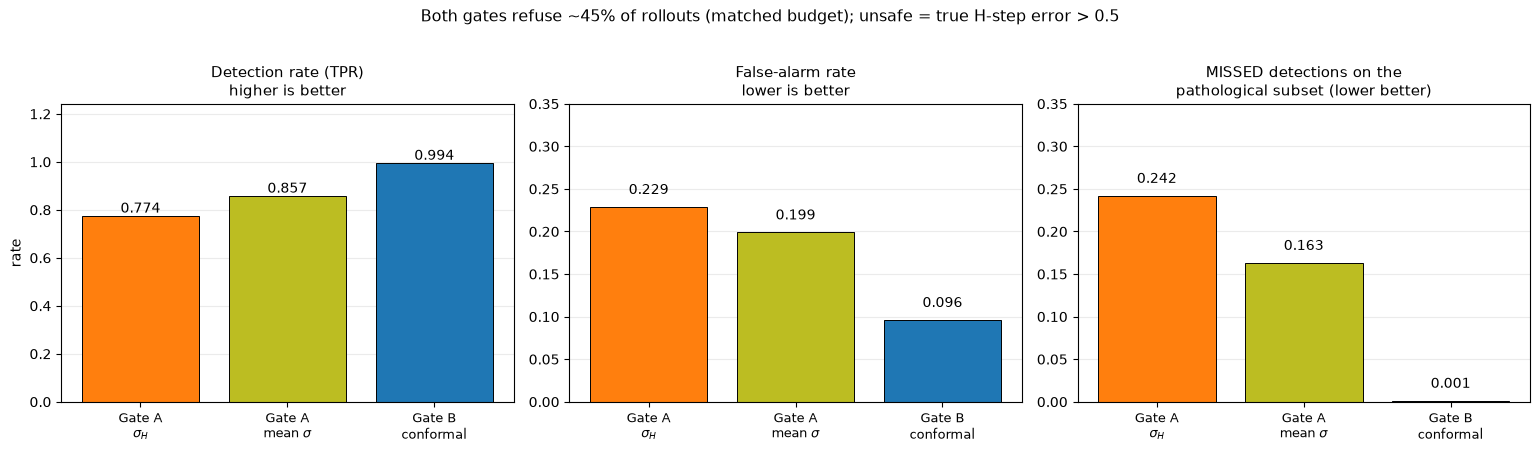

Same alarm budget, same rollouts, same horizon — only the score differs.
  Gate A: disagreement (sigma_H)   TPR 0.774 | false alarms 0.229 | missed on pathological 0.242
  Gate A: disagreement (mean)      TPR 0.857 | false alarms 0.199 | missed on pathological 0.163
  Gate B: split conformal          TPR 0.994 | false alarms 0.096 | missed on pathological 0.001


In [15]:
# [Result 03] Gate comparison at a matched alarm budget
names = list(tbl.keys())
short = ["Gate A\n$\\sigma_H$", "Gate A\nmean $\\sigma$", "Gate B\nconformal"]
cols  = ["tab:orange", "tab:olive", "tab:blue"]

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.4))

x = np.arange(len(names))
for a, key, ttl, good in [(ax[0], "tpr",    "Detection rate (TPR)\nhigher is better", True),
                          (ax[1], "far",    "False-alarm rate\nlower is better", False),
                          (ax[2], "miss_p", "MISSED detections on the\npathological subset (lower better)", False)]:
    v = [tbl[n][key] for n in names]
    bars = a.bar(x, v, color=cols, edgecolor="k", lw=0.7)
    for b_, vv in zip(bars, v):
        a.text(b_.get_x() + b_.get_width() / 2, vv + 0.015, f"{vv:.3f}", ha="center", fontsize=10)
    a.set_xticks(x); a.set_xticklabels(short, fontsize=9)
    a.set_ylim(0, max(0.35, max(v) * 1.25)); a.set_title(ttl, fontsize=11)
    a.grid(axis="y", alpha=0.25); a.set_axisbelow(True)
ax[0].set_ylabel("rate")
fig.suptitle(f"Both gates refuse ~{budget*100:.0f}% of rollouts (matched budget); "
             f"unsafe = true H-step error > {TAU}", fontsize=11.5, y=1.02)
plt.tight_layout(); plt.show()

print("Same alarm budget, same rollouts, same horizon — only the score differs.")
for n in names:
    print(f"  {n:<32} TPR {tbl[n]['tpr']:.3f} | false alarms {tbl[n]['far']:.3f} | "
          f"missed on pathological {tbl[n]['miss_p']:.3f}")

**[Callout 04]**

### Engineering callout: a matched budget is the only fair comparison — and it is easy to fake

The seductive mistake is to compare Gate A at a threshold you tuned *on test* against Gate B at whatever threshold its theory produced. Every number in the table above moves if you slide `thr_A`, and the direction is under your control: push it down and Gate A's TPR climbs while its false alarms explode; push it up and the reverse. A bar chart with unmatched operating points is decoration.

Three rules we followed, in order of how often they get broken:

1. **Derive the budget from the gate that has no free parameter.** Gate B's refusal rate is pinned by $(\tau, \alpha)$; Gate A's threshold is free. So Gate B sets the budget and Gate A matches it, never the other way round.
2. **Match on the calibration split, never on test.** `thr_A` is a quantile of calibration scores. Using test scores to set it leaks the answer and inflates Gate A.
3. **Assert the match survived.** Quantile matching on one split only *approximately* transfers to another; we assert the realised test alarm rates agree to within 5 points, and they do.

**Lesson:** whenever two detectors are compared, the first question is "at what operating point?" and the second is "who chose it, using what data?". If a comparison cannot answer both, its ranking is a free parameter. The honest alternative is to sweep the threshold and show the whole curve — a single matched point is the cheap version of that, and it is the minimum bar.

**[Text 08]**

## An Ablation: Did We Compare the Methods, or the Inputs?

Before banking that result, look at what Gate B was actually eating. Its error predictor $h(x)$ takes nine deployment-observable features, and one of them is `log1p knn5(z0)` — the distance from the start state to its five nearest training states. In this staged setup that feature is very nearly a **direct readout of the thing that causes the error**: we manufactured the pathology by starting rollouts outside the training support, so "how far outside the support am I" and "how wrong is this rollout about to be" are close to the same question.

Gate A never saw that feature. It scores on ensemble spread and nothing else. So the table above is consistent with two very different explanations:

1. **The conformal wrapper wins.** Calibrating against measured residuals is what beats asking the model how it feels.
2. **Gate B was handed a better input.** Any method with access to the novelty feature would have done about as well, and the wrapper is along for the ride.

Those have different consequences for what you should build, and the experiment so far cannot separate them. The fix is cheap: give the *simplest possible* method the *same* information and see how much of the gap survives.

**Gate C — raw novelty, no conformal.** Threshold `log1p knn5(z0)` directly. No error predictor, no calibration set, no $\hat q$, no coverage statement, no $\tau$ — just *refuse if the start state is too far from the training data*, at the same alarm budget Gate B set and Gate A matched. If Gate C lands near Gate B, explanation (2) is doing most of the work and the headline needs rewriting.

In [16]:
# [Code 13] ABLATION - Gate C: threshold the novelty feature directly, no conformal wrapper
NOV = FEAT_NAMES.index("log1p knn5(z0)")
nov_ca_f, nov_te_f = X_ca[:, NOV], X_te[:, NOV]      # already computed above: consumes NO new randomness
thr_C = np.quantile(nov_ca_f, 1 - budget)            # SAME budget, SAME calibration split as Gate A

kA, kA2 = "Gate A: disagreement (sigma_H)", "Gate A: disagreement (mean)"
kB, kC  = "Gate B: split conformal", "Gate C: raw novelty (no conformal)"
refuse_abl = dict(refuse); refuse_abl[kC] = nov_te_f > thr_C

def score_gate(rf):
    tp = int(np.sum(rf & unsafe)); fn = int(np.sum(~rf & unsafe))
    fp = int(np.sum(rf & ~unsafe)); tn = int(np.sum(~rf & ~unsafe))
    return dict(tp=tp, fn=fn, fp=fp, tn=tn, tpr=tp / (tp + fn), far=fp / (fp + tn),
                miss_p=float(np.mean(~rf[pathological])), risk=fn / max(fn + tn, 1),
                alarm=float(rf.mean()))
tbl_abl = {n: score_gate(rf) for n, rf in refuse_abl.items()}

print(f"Gate C rule: log1p(knn5(z0)) > {thr_C:.3f}  ==  mean 5-NN distance > {np.expm1(thr_C):.3f} latent units")
print("log1p is monotone, so this is literally: refuse if the start state is too far from the training data.")
print(f"realised test alarm rate {tbl_abl[kC]['alarm']:.3f} vs matched budget {budget:.3f}\n")

print(f"{'gate':<37}{'sees':<25}{'TPR':>7}{'false alarm':>13}{'MISSED|path':>13}{'unsafe|accepted':>17}")
sees = {kA: "spread", kA2: "spread", kB: "spread + novelty + ...", kC: "novelty"}
for n in [kA, kA2, kB, kC]:
    v = tbl_abl[n]
    print(f"{n:<37}{sees[n]:<25}{v['tpr']:>7.3f}{v['far']:>13.3f}{v['miss_p']:>13.3f}{v['risk']:>17.3f}")

assert abs(tbl_abl[kC]["alarm"] - budget) < 0.05, "Gate C must spend the same alarm budget as A and B"

# --- how much of the A->B gap does the FEATURE alone recover? -------------------
best_A  = max([kA, kA2], key=lambda k: tbl_abl[k]["tpr"])          # give Gate A its best variant
gap_AB  = tbl_abl[kB]["tpr"] - tbl_abl[best_A]["tpr"]
gap_AC  = tbl_abl[kC]["tpr"] - tbl_abl[best_A]["tpr"]
closed  = gap_AC / gap_AB
print(f"\nBest Gate A variant = '{best_A.split(':')[1].strip()}' at TPR {tbl_abl[best_A]['tpr']:.3f}.")
print(f"Gate A -> Gate B is +{gap_AB:.3f} TPR.  Gate A -> Gate C (feature only) is +{gap_AC:.3f} TPR.")
print(f"The bare novelty threshold recovers {closed*100:.0f}% of the gap without any conformal machinery.")

if closed >= 0.6:
    print("\nVERDICT: most of Gate B's advantage here is the FEATURE, not the conformal wrapper.")
    print(f"  A four-line threshold on one input reaches TPR {tbl_abl[kC]['tpr']:.3f} against conformal's "
          f"{tbl_abl[kB]['tpr']:.3f},")
    print(f"  and {tbl_abl[kC]['miss_p']*100:.1f}% missed on the pathological subset against "
          f"{tbl_abl[kB]['miss_p']*100:.1f}%.")
    print("  Conformal keeps a real but MODEST edge in ranking; the headline 'conformal beats ensembles'")
    print("  is not what this experiment shows.")
    assert closed >= 0.6
else:
    print("\nVERDICT: the conformal wrapper is carrying real weight - the feature alone does not explain it.")
    print(f"  With the same input, the bare threshold reaches only TPR {tbl_abl[kC]['tpr']:.3f} against "
          f"conformal's {tbl_abl[kB]['tpr']:.3f}.")
    assert closed < 0.6
assert tbl_abl[kB]["tpr"] >= tbl_abl[kC]["tpr"], "reported ordering: conformal is at least as good as the ablation"

# --- so what DOES the wrapper buy, if not ranking power? ------------------------
print("\nWhat the wrapper buys instead of ranking power: a threshold you can defend.")
print(f"{'tolerance tau':>14}{'Gate B alarm':>14}{'Gate C thr':>13}   how the operating point was chosen")
for tau2 in (0.25, 0.5, 1.0, 2.0):
    b2 = float(np.mean(bound(X_ca) > tau2))            # Gate B: implied by (tau, alpha) alone
    t2 = float(np.quantile(nov_ca_f, 1 - b2))          # Gate C: back-solved from Gate B's budget
    print(f"{tau2:>14.2f}{b2:>14.3f}{t2:>13.3f}   B: from (tau={tau2}, alpha={ALPHA}) | C: back-solved")
print(f"\nGate B's operating point falls out of the safety requirement: tau is in LATENT ERROR UNITS and")
print(f"  the bound carries a measured {coverage:.4f} marginal coverage against a nominal {1-ALPHA:.2f}.")
print(f"Gate C's threshold ({thr_C:.3f}) is a magic number on an uncalibrated score. It has no units of")
print( "  error, no coverage statement, and above it could only be chosen by BACK-SOLVING from Gate B's")
print( "  budget - i.e. from labelled errors it does not otherwise need.")
print("That is a genuine benefit, and it is a DIFFERENT benefit from raw ranking power. Do not conflate them.")
assert coverage >= 1 - ALPHA - 0.03, "Gate B's bound is certified; Gate C's threshold is not"

print(f"\nOne more asymmetry worth saying out loud: Gate A was never given '{FEAT_NAMES[NOV]}'.")
print("The fair reading of this whole section is 'a residual-calibrated bound on good observable features")
print("beats ensemble spread alone' - NOT 'conformal beats ensembles'.")
assert "log1p knn5(z0)" in FEAT_NAMES and FEAT_NAMES[NOV] == "log1p knn5(z0)"

Gate C rule: log1p(knn5(z0)) > 0.320  ==  mean 5-NN distance > 0.378 latent units
log1p is monotone, so this is literally: refuse if the start state is too far from the training data.
realised test alarm rate 0.447 vs matched budget 0.453

gate                                 sees                         TPR  false alarm  MISSED|path  unsafe|accepted
Gate A: disagreement (sigma_H)       spread                     0.774        0.229        0.242            0.162
Gate A: disagreement (mean)          spread                     0.857        0.199        0.163            0.106
Gate B: split conformal              spread + novelty + ...     0.994        0.096        0.001            0.005
Gate C: raw novelty (no conformal)   novelty                    0.970        0.101        0.026            0.022

Best Gate A variant = 'disagreement (mean)' at TPR 0.857.
Gate A -> Gate B is +0.137 TPR.  Gate A -> Gate C (feature only) is +0.113 TPR.
The bare novelty threshold recovers 83% of the gap witho

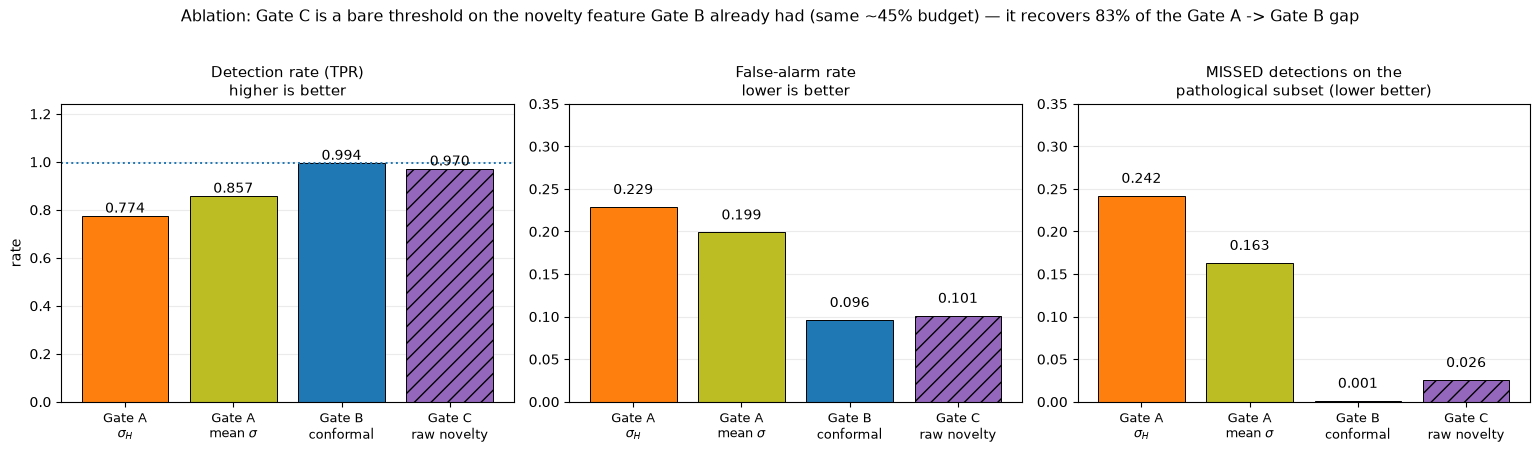

gate                                  TPR  false alarm  MISSED|path
Gate A: disagreement (sigma_H)      0.774        0.229        0.242
Gate A: disagreement (mean)         0.857        0.199        0.163
Gate B: split conformal             0.994        0.096        0.001
Gate C: raw novelty (no conformal)  0.970        0.101        0.026

Same budget, same rollouts. The purple bar had none of the conformal machinery — only the feature.


In [17]:
# [Result 04] The ablation: the same three metrics, with the feature-only baseline alongside
names_abl = [kA, kA2, kB, kC]
short_abl = ["Gate A\n$\\sigma_H$", "Gate A\nmean $\\sigma$", "Gate B\nconformal", "Gate C\nraw novelty"]
cols_abl  = ["tab:orange", "tab:olive", "tab:blue", "tab:purple"]
hat_abl   = ["", "", "", "//"]                      # hatched = the ablation baseline

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.4))

x = np.arange(len(names_abl))
for a, key, ttl in [(ax[0], "tpr",    "Detection rate (TPR)\nhigher is better"),
                    (ax[1], "far",    "False-alarm rate\nlower is better"),
                    (ax[2], "miss_p", "MISSED detections on the\npathological subset (lower better)")]:
    v = [tbl_abl[n][key] for n in names_abl]
    bars = a.bar(x, v, color=cols_abl, edgecolor="k", lw=0.7, hatch=hat_abl)
    for b_, vv in zip(bars, v):
        a.text(b_.get_x() + b_.get_width() / 2, vv + 0.015, f"{vv:.3f}", ha="center", fontsize=10)
    a.set_xticks(x); a.set_xticklabels(short_abl, fontsize=9)
    a.set_ylim(0, max(0.35, max(v) * 1.25)); a.set_title(ttl, fontsize=11)
    a.grid(axis="y", alpha=0.25); a.set_axisbelow(True)
ax[0].set_ylabel("rate")
ax[0].axhline(tbl_abl[kB]["tpr"], color="tab:blue", ls=":", lw=1.4)
fig.suptitle(f"Ablation: Gate C is a bare threshold on the novelty feature Gate B already had "
             f"(same ~{budget*100:.0f}% budget) — it recovers {closed*100:.0f}% of the Gate A -> Gate B gap",
             fontsize=11.5, y=1.02)
plt.tight_layout(); plt.show()

print(f"{'gate':<34}{'TPR':>7}{'false alarm':>13}{'MISSED|path':>13}")
for n in names_abl:
    v = tbl_abl[n]
    print(f"{n:<34}{v['tpr']:>7.3f}{v['far']:>13.3f}{v['miss_p']:>13.3f}")
print(f"\nSame budget, same rollouts. The purple bar had none of the conformal machinery — "
      f"only the feature.")

**[Callout 05]**

### Engineering callout: a gate comparison is a feature comparison in disguise

Two safety signals went into that first bar chart and one of them won decisively, so the natural sentence to write is *"method B beats method A."* But Gate B and Gate A did not differ only in method — they differed in **what they were allowed to look at**. Gate B's $h(x)$ was handed a novelty feature that is close to a direct measurement of the staged failure's cause; Gate A was handed the ensemble's opinion of itself and nothing else. Once you notice that, the original claim is unfalsifiable from the original experiment.

```python
# What the first chart actually compared: two methods AND two different input sets
gate_A = spread_H > thr_A                            # sees: ensemble spread
gate_B = h([novelty, spread, radius, ...]) + q_hat > TAU   # sees: spread AND novelty

# The ablation, which costs four lines: same information, simplest possible method
thr_C  = np.quantile(novelty_cal, 1 - budget)        # same budget, same split
gate_C = novelty > thr_C                             # sees: novelty
```

**Lesson:** when you compare two safety signals, ask whether you compared the *methods* or the *inputs*, because a benchmark table cannot tell you which. The diagnostic is cheap and you should run it before you write the conclusion: hand the **simplest baseline the same information** the winner had, hold the operating point fixed, and see how much of the margin survives. If most of it evaporates, your result is a feature-engineering result wearing a methods-result costume — still useful, but a different sentence, pointing at different work. And if the sophisticated method keeps only a narrow edge, say what it *does* still buy: here, a threshold in the units of the thing you care about, with a coverage number attached, instead of a cut on a score whose scale means nothing.

**[Text 09]**

## Conformal Is Not Magic: Marginal Coverage and the Exchangeability Assumption

Gate B still leads after the ablation — narrowly on ranking, clearly on interpretability — so this is the moment to attack it rather than take a victory lap.

The theorem says: for **exchangeable** $(x_i, e_i)$, $\Pr(e \le h(x)+\hat q) \ge 1-\alpha$. Two words carry all the risk.

**Marginal.** The probability is over the *whole* test distribution. It says nothing about any particular subgroup. A predictor can hit 90% overall while covering 97% of easy rollouts and 78% of the rollouts you actually care about — and averaging hides it.

**Exchangeable.** Calibration and test rollouts must be drawable in any order from the same joint distribution. A deployed agent breaks this immediately, because **it chooses its own actions**. A planner that prefers plans the model likes will systematically over-sample exactly the plans where the model is optimistic — which is [Biased Dreams](https://arxiv.org/abs/2604.25416)' point restated as a statistical one, and the reason [Foresight](https://arxiv.org/abs/2606.23085) and [Learning from World Feedback](https://arxiv.org/abs/2607.16591) keep pulling real outcomes back into the loop.

We test both. First conditional coverage by novelty; then a **closed-loop** experiment where a planner selects, from 24 candidate action sequences, the one the ensemble is most confident about — a disagreement-averse planner, which is exactly what the ensemble-gating literature recommends you build.

In [18]:
# [Code 14] Counter-experiment: conditional coverage, then closed-loop action selection
print(f"MARGINAL coverage (the headline number): {coverage:.4f}\n")

# (a) conditional on novelty of the start state
nov = np.log1p(knn_dist(z0_te))
edges = np.quantile(nov, np.linspace(0, 1, 6))
resid_te = np.log(e_te + EPS) - h(X_te)          # the quantity q_hat is supposed to bound
cond_cov, cond_lbl, cond_err, cond_res = [], [], [], []
print(f"{'novelty quintile':<18}{'n':>6}{'coverage':>11}{'mean true err':>15}"
      f"{'90th pct resid':>16}   (q_hat = {q_hat:.3f})")
for i in range(5):
    m = (nov >= edges[i]) & (nov <= edges[i + 1])
    c = float(np.mean(e_te[m] <= B_te[m]))
    r90 = float(np.percentile(resid_te[m], 90))
    cond_cov.append(c); cond_lbl.append(f"Q{i+1}"); cond_err.append(e_te[m].mean()); cond_res.append(r90)
    flag = "  <-- exceeds q_hat" if r90 > q_hat else ""
    print(f"{'Q'+str(i+1)+' (least..most)':<18}{m.sum():>6}{c:>11.3f}{e_te[m].mean():>15.3f}{r90:>16.3f}{flag}")
worst_i = int(np.argmin(cond_cov))
print(f"\nWorst quintile: Q{worst_i+1} at {cond_cov[worst_i]:.3f} vs marginal {coverage:.3f} "
      f"-> {100*(coverage-cond_cov[worst_i]):.1f} points BELOW the headline.")
print(f"Coverage is NOT monotone in novelty (Q5 = {cond_cov[-1]:.3f}). The mechanism is in the last column:")
print(f"  q_hat = {q_hat:.3f} is ONE global constant, but each subgroup has its own residual distribution.")
print(f"  A subgroup is covered at 90% exactly when its own 90th-percentile residual sits below q_hat.")
print(f"  Q{int(np.argmax(cond_res))+1} has the largest 90th-pct residual ({max(cond_res):.3f}) and the worst coverage;")
print(f"  the far tail Q5 recovers ({cond_res[-1]:.3f} < q_hat) because h predicts large errors there and the")
print(f"  log-space band is multiplicative, so it is absolutely wide. Marginal coverage averages all of this away.")
assert cond_res[worst_i] > q_hat, "the undercovered subgroup must be the one whose residuals exceed q_hat"

# (b) closed loop: a disagreement-averse planner picks its own actions
M_CAND = 24
def plan_min_disagreement(z0, rg, M=M_CAND):
    n = len(z0)
    best = np.full(n, np.inf); chosen = np.empty((n, H, 2))
    for _ in range(M):
        cand = sample_actions(n, rg)
        o = roll(z0, cand)
        score = o["spread"][:, 1:].mean(1)          # prefer the plan the ensemble agrees on
        upd = score < best
        best[upd] = score[upd]; chosen[upd] = cand[upd]
    return chosen

rg_cl = np.random.default_rng(123)
z0_cl, A_iid = make_set(600, rg_cl)
o_iid = roll(z0_cl, A_iid)
cov_iid = float(np.mean(o_iid["err"][:, -1] <= bound(features(z0_cl, A_iid, o_iid))))

A_pl = plan_min_disagreement(z0_cl, rg_cl)
o_pl = roll(z0_cl, A_pl)
e_pl = o_pl["err"][:, -1]
cov_pl = float(np.mean(e_pl <= bound(features(z0_cl, A_pl, o_pl))))

print(f"\nSAME start states, {len(z0_cl)} rollouts:")
print(f"  i.i.d. actions (exchangeable with calibration): coverage {cov_iid:.3f}, "
      f"mean disagreement {o_iid['spread'][:,1:].mean():.4f}, mean true error {o_iid['err'][:,-1].mean():.2f}")
print(f"  planner-selected actions (NOT exchangeable)   : coverage {cov_pl:.3f}, "
      f"mean disagreement {o_pl['spread'][:,1:].mean():.4f}, mean true error {e_pl.mean():.2f}")
d_conf = 100 * (1 - o_pl["spread"][:, 1:].mean() / o_iid["spread"][:, 1:].mean())
d_err  = 100 * (e_pl.mean() / o_iid["err"][:, -1].mean() - 1)
print(f"\nThe planner cut ensemble disagreement by {d_conf:.0f}% and changed true error by {d_err:+.0f}%.")
if d_conf > 10 and abs(d_err) < 10:
    print("  -> It made the model LOOK more confident without making it any more accurate.")
elif d_conf > 10:
    print(f"  -> It made the model look more confident; true error also moved {d_err:+.0f}%.")
else:
    print("  -> The planner barely shifted the confidence distribution; read the coverage gap with care.")
print(f"Coverage under the planner's own action distribution: {cov_pl:.3f} — "
      f"{'BELOW' if cov_pl < 1 - ALPHA else 'at or above'} the nominal {1-ALPHA:.2f}, and "
      f"{100*(cov_iid - cov_pl):.1f} points below the i.i.d. rollouts it was calibrated against.")
assert cov_pl < cov_iid, "closed-loop selection should degrade coverage relative to i.i.d. actions"

MARGINAL coverage (the headline number): 0.8990

novelty quintile       n   coverage  mean true err  90th pct resid   (q_hat = 0.821)
Q1 (least..most)     400      0.950          0.028           0.701
Q2 (least..most)     400      0.968          0.029           0.586
Q3 (least..most)     400      0.850          0.824           1.179  <-- exceeds q_hat
Q4 (least..most)     400      0.765          3.720           1.318  <-- exceeds q_hat
Q5 (least..most)     400      0.963          6.383           0.556

Worst quintile: Q4 at 0.765 vs marginal 0.899 -> 13.4 points BELOW the headline.
Coverage is NOT monotone in novelty (Q5 = 0.963). The mechanism is in the last column:
  q_hat = 0.821 is ONE global constant, but each subgroup has its own residual distribution.
  A subgroup is covered at 90% exactly when its own 90th-percentile residual sits below q_hat.
  Q4 has the largest 90th-pct residual (1.318) and the worst coverage;
  the far tail Q5 recovers (0.556 < q_hat) because h predicts lar


SAME start states, 600 rollouts:
  i.i.d. actions (exchangeable with calibration): coverage 0.912, mean disagreement 0.0810, mean true error 2.26
  planner-selected actions (NOT exchangeable)   : coverage 0.868, mean disagreement 0.0514, mean true error 2.33

The planner cut ensemble disagreement by 37% and changed true error by +3%.
  -> It made the model LOOK more confident without making it any more accurate.
Coverage under the planner's own action distribution: 0.868 — BELOW the nominal 0.90, and 4.3 points below the i.i.d. rollouts it was calibrated against.


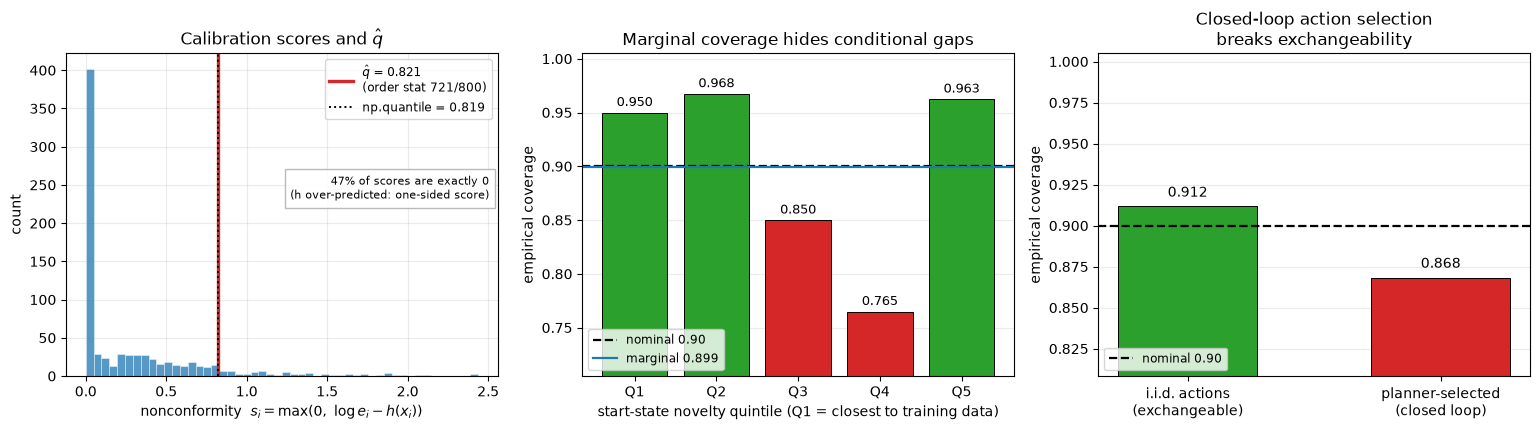

nominal 0.90 | marginal 0.899 | worst novelty quintile 0.765 | closed loop 0.868


In [19]:
# [Result 05] Conformal calibration and where its guarantee stops holding
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.4))

ax[0].hist(s_ca, bins=50, color="tab:blue", alpha=0.75, edgecolor="white", lw=0.4)
ax[0].axvline(q_hat, color="tab:red", lw=2.4,
              label=f"$\\hat q$ = {q_hat:.3f}\n(order stat {int(np.ceil((len(s_ca)+1)*(1-ALPHA)))}/{len(s_ca)})")
ax[0].axvline(q_naive, color="k", lw=1.4, ls=":", label=f"np.quantile = {q_naive:.3f}")
ax[0].set_xlabel("nonconformity  $s_i=\\max(0,\\ \\log e_i - h(x_i))$")
ax[0].set_ylabel("count"); ax[0].set_title("Calibration scores and $\\hat q$")
ax[0].legend(fontsize=8.5); ax[0].grid(alpha=0.25); ax[0].set_axisbelow(True)
ax[0].text(0.98, 0.55, f"{np.mean(s_ca==0)*100:.0f}% of scores are exactly 0\n(h over-predicted: "
           f"one-sided score)", transform=ax[0].transAxes, ha="right", fontsize=8,
           bbox=dict(fc="white", ec="0.7", alpha=0.9))

bars = ax[1].bar(cond_lbl, cond_cov, color=["tab:green" if c >= 1 - ALPHA else "tab:red" for c in cond_cov],
                 edgecolor="k", lw=0.7)
for b_, c in zip(bars, cond_cov):
    ax[1].text(b_.get_x() + b_.get_width() / 2, c + 0.006, f"{c:.3f}", ha="center", fontsize=9)
ax[1].axhline(1 - ALPHA, color="k", ls="--", lw=1.6, label=f"nominal {1-ALPHA:.2f}")
ax[1].axhline(coverage, color="tab:blue", ls="-", lw=1.6, label=f"marginal {coverage:.3f}")
ax[1].set_ylim(min(cond_cov) - 0.06, 1.005)
ax[1].set_xlabel("start-state novelty quintile (Q1 = closest to training data)")
ax[1].set_ylabel("empirical coverage")
ax[1].set_title("Marginal coverage hides conditional gaps")
ax[1].legend(fontsize=8.5, loc="lower left"); ax[1].grid(axis="y", alpha=0.25); ax[1].set_axisbelow(True)

lbl2 = ["i.i.d. actions\n(exchangeable)", "planner-selected\n(closed loop)"]
v2 = [cov_iid, cov_pl]
bars = ax[2].bar(lbl2, v2, color=["tab:green" if v >= 1 - ALPHA else "tab:red" for v in v2],
                 edgecolor="k", lw=0.7, width=0.55)
for b_, v in zip(bars, v2):
    ax[2].text(b_.get_x() + b_.get_width() / 2, v + 0.006, f"{v:.3f}", ha="center", fontsize=10)
ax[2].axhline(1 - ALPHA, color="k", ls="--", lw=1.6, label=f"nominal {1-ALPHA:.2f}")
ax[2].set_ylim(min(v2) - 0.06, 1.005); ax[2].set_ylabel("empirical coverage")
ax[2].set_title("Closed-loop action selection\nbreaks exchangeability")
ax[2].legend(fontsize=8.5, loc="lower left"); ax[2].grid(axis="y", alpha=0.25); ax[2].set_axisbelow(True)

plt.tight_layout(); plt.show()

print(f"nominal {1-ALPHA:.2f} | marginal {coverage:.3f} | worst novelty quintile {min(cond_cov):.3f} "
      f"| closed loop {cov_pl:.3f}")

**[Callout 06]**

### Engineering callout: exchangeability is an assumption you maintain, not a property you inherit

Nothing about the calibration changed between those two bars. Same $h$, same $\hat q$, same start states, same horizon. The only difference is **who chose the actions** — and that was enough to push coverage under nominal.

**What went wrong (during construction):** our first closed-loop experiment used a goal-directed planner (pick the plan whose imagined final state lands nearest a target). It barely moved coverage, and we nearly shipped it as evidence that closed-loop control is fine.

```python
# Weak probe: a goal-seeking planner is only mildly correlated with model error
score = np.linalg.norm(o["imag"][:, -1] - goal, axis=1)     # coverage barely moved

# Sharp probe: select on the model's OWN confidence and the bias is immediate
score = o["spread"][:, 1:].mean(1)                          # coverage falls below nominal
```

The distinction matters because the sharp probe is not a strawman — **preferring low-disagreement plans is the standard recommendation.** A disagreement-averse planner is a selection operator pointed straight at the statistic the ensemble is worst at, so it concentrates probability on precisely the rollouts the pathology produces. A negative result from a weak probe is not evidence of robustness; it is evidence you chose a weak probe.

**Lesson:** report conditional coverage on the slices you care about, and re-validate whenever the policy changes — a conformal gate calibrated under one action distribution is not certified under another. The cheap mitigations are all forms of restoring exchangeability: calibrate on rollouts drawn from the *deployed* policy rather than a data-collection policy, recalibrate online from executed outcomes (the [Learning from World Feedback](https://arxiv.org/abs/2607.16591) direction), or fall back to a weighted / adaptive conformal variant that budgets explicitly for shift. What you must not do is quote the marginal number and stop.

**[Text 10]**

## What We Built, and What's Next

Three gates, same rollouts, same horizon, same alarm budget. **Gate A** asked the model how sure it was. **Gate B** ignored the model's opinion entirely and asked instead: *on held-out rollouts that looked like this one, how big did the error actually get?* **Gate C** was the ablation that keeps us honest about why Gate B won. On a staged Biased-Dreams pathology, the gap between asking the model and measuring against reality is the difference between catching the failure and executing it.

The sibling notebook, `00_uncertainty_aware_mpc`, propagates the posterior through the horizon and plans against it — and that is the right thing to do **when the posterior is trustworthy**. This notebook is the other half of the sentence. Propagating uncertainty helps exactly to the extent that the uncertainty is honest; when the model's uncertainty is a function of the same data skew that caused the error, propagating it faithfully propagates a lie. The remedy is not a better prior, it is a **different measurement**: stop asking the model and start measuring against something outside it. But be precise about which part of Gate B did the work. Ensemble spread is a *model-internal* quantity, and Gate B's margin over it came mostly from an *external* one — a novelty feature Gate A never saw, which a bare threshold (Gate C) exploited almost as well with none of the conformal machinery. What the conformal wrapper still earns, once the ablation has taken the ranking claim away, is the **threshold itself**: $\tau$ in the units of the error you actually care about, carrying a finite-sample $1-\alpha$ coverage guarantee, instead of a magic cut on an uncalibrated score. That is a smaller claim than "conformal degrades gracefully where ensembles do not", and it is the one the experiments support.

Four things this notebook is not:

- **It is not a replication.** The pathology is staged — we chose the data skew, the length-scale, and the start states until the two signals separated. [Biased Dreams (Berger et al., RLC 2026)](https://arxiv.org/abs/2604.25416) is cited for the phenomenon, not reproduced. At this scale the failure does not arise on its own.
- **It is not a demonstration that conformal beats ensembles.** Gate B's error predictor was fed a k-NN novelty feature that, in this staged setup, is close to a direct readout of the failure's cause; Gate A only ever saw ensemble spread. The Gate C ablation gave a bare threshold that same feature and recovered most of the margin. The defensible sentence is *a residual-calibrated bound on good observable features beats ensemble spread alone* — which is as much a statement about the features as about the method.
- **It is not a claim that conformal is safe.** Marginal coverage held; conditional coverage did not, and closed-loop action selection degraded it further. A gate that is valid on average and invalid on the subgroup that kills you is a liability with good paperwork.
- **It is not a complete safety case.** $\tau$ was a number we chose, `unsafe` was defined by an oracle we happened to have, and every gate had the luxury of an offline set with ground-truth rollouts. Real systems get that ground truth from execution, which is precisely where [Foresight](https://arxiv.org/abs/2606.23085) and [Pixels to Proofs](https://arxiv.org/abs/2606.15594) push: verify against something outside the model.

The practical takeaway is small and durable. Ensembles are a fine *first* filter — on benign rollouts disagreement correlated positively with error, and it is nearly free. But it is a filter that fails silently, and it fails hardest on the states where your data was thinnest, which are the states you deployed into. Feed your gate an explicit measure of *that* — how far outside the training support you are — because most of the detection power here lived in that feature. Then wrap it in a residual-calibrated bound so the threshold means something, match your operating points before you believe any comparison, ablate the winner against the simplest baseline holding the same inputs, and report the conditional coverage next to the marginal one.